<a href="https://colab.research.google.com/github/luciaPi/MLSS2026-generative-models/blob/main/3_cGAN_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Conditional GAN (cGAN) na MNIST


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Používam zariadenie: {device}")

Používam zariadenie: cuda


In [ ]:
# Hyperparametre
BATCH_SIZE = 128
EPOCHS = 50
LATENT_DIM = 200 # velkost latentneho priestoru
NUM_CLASSES = 10
EMBEDDING_DIM = 50 # velkost conditional embeddingu
LR_G = 0.0002 # rychlost ucenia generatora
LR_D = 0.0002 # rychlost ucenia diskriminatora

# Dáta
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

print(f"Dataset size: {len(train_dataset)}")

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.87MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.3MB/s]

Dataset size: 60000


## 2. Conditional Generator

In [ ]:
class ConditionalGenerator(nn.Module):
    def __init__(self, latent_dim=100, num_classes=10, embedding_dim=50):
        super(ConditionalGenerator, self).__init__()

        # Label embedding
        self.label_embedding = nn.Embedding(num_classes, embedding_dim) # podmienka

        # Generator prijíma šum + embedded label
        self.model = nn.Sequential(
            nn.Linear(latent_dim + embedding_dim, 256), # latentny vektor + podmienka
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(256),

            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(512),

            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(1024),

            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, z, labels):
        # Embed labels
        label_emb = self.label_embedding(labels)  # podmienka

        # Concatenate šum a label
        gen_input = torch.cat([z, label_emb], dim=1)

        img = self.model(gen_input)
        img = img.view(img.size(0), 1, 28, 28)
        return img

generator = ConditionalGenerator(LATENT_DIM, NUM_CLASSES, EMBEDDING_DIM).to(device)
print("Conditional Generator:")
print(generator)
print(f"\nParametre: {sum(p.numel() for p in generator.parameters())}")

Conditional Generator:
ConditionalGenerator(
  (label_embedding): Embedding(10, 50)
  (model): Sequential(
    (0): Linear(in_features=250, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=256, out_features=512, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Linear(in_features=512, out_features=1024, bias=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): Linear(in_features=1024, out_features=784, bias=True)
    (10): Tanh()
  )
)

Parametre: 1528836


## 3. Conditional Discriminator

In [ ]:
class ConditionalDiscriminator(nn.Module):
    def __init__(self, num_classes=10, embedding_dim=50):
        super(ConditionalDiscriminator, self).__init__()

        # Label embedding
        self.label_embedding = nn.Embedding(num_classes, embedding_dim) # podmienka

        # Discriminator prijíma obrázok + embedded label
        self.model = nn.Sequential(
            nn.Linear(784 + embedding_dim, 512), # latentny vektor + podmienka
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256, 1),
            nn.Sigmoid() # pravdepodobnost, ze je obrazok realny
        )

    def forward(self, img, labels):
        # Flatten image
        img_flat = img.view(img.size(0), -1)

        # Embed labels
        label_emb = self.label_embedding(labels) # podmienka

        # Concatenate
        d_input = torch.cat([img_flat, label_emb], dim=1)

        validity = self.model(d_input)
        return validity

discriminator = ConditionalDiscriminator(NUM_CLASSES, EMBEDDING_DIM).to(device)
print("Conditional Discriminator:")
print(discriminator)
print(f"\nParametre: {sum(p.numel() for p in discriminator.parameters())}")

Conditional Discriminator:
ConditionalDiscriminator(
  (label_embedding): Embedding(10, 50)
  (model): Sequential(
    (0): Linear(in_features=834, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

Parametre: 559605


In [ ]:
# Loss a optimizéry
adversarial_loss = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=LR_G, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR_D, betas=(0.5, 0.999))

## 4. Trénovanie

TRÉNOVANIE CONDITIONAL GAN
Epocha [1/50] | D Loss: 0.0696 | G Loss: 4.8280 | D Acc: 98.2%
Epocha [2/50] | D Loss: 0.0015 | G Loss: 8.4893 | D Acc: 100.0%
Epocha [3/50] | D Loss: 0.1334 | G Loss: 8.4356 | D Acc: 97.2%
Epocha [4/50] | D Loss: 0.2408 | G Loss: 4.2896 | D Acc: 89.6%
Epocha [5/50] | D Loss: 0.3150 | G Loss: 3.5495 | D Acc: 85.7%
Epocha [6/50] | D Loss: 0.3283 | G Loss: 3.8271 | D Acc: 84.8%
Epocha [7/50] | D Loss: 0.3177 | G Loss: 3.6976 | D Acc: 85.7%
Epocha [8/50] | D Loss: 0.3481 | G Loss: 3.0105 | D Acc: 84.4%
Epocha [9/50] | D Loss: 0.3474 | G Loss: 3.0918 | D Acc: 84.7%
Epocha [10/50] | D Loss: 0.4006 | G Loss: 2.0406 | D Acc: 81.9%


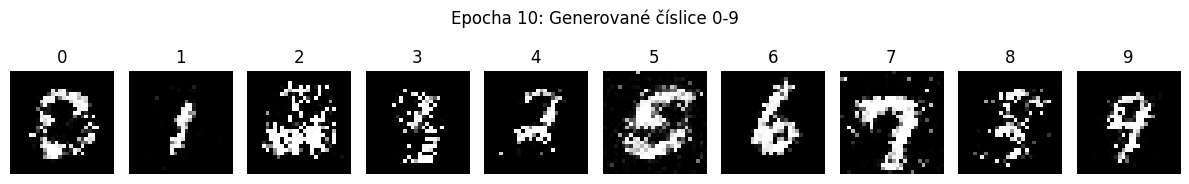

Epocha [11/50] | D Loss: 0.3942 | G Loss: 2.0173 | D Acc: 82.3%
Epocha [12/50] | D Loss: 0.3609 | G Loss: 2.1811 | D Acc: 84.2%
Epocha [13/50] | D Loss: 0.3847 | G Loss: 2.0473 | D Acc: 82.9%
Epocha [14/50] | D Loss: 0.3952 | G Loss: 2.0059 | D Acc: 82.3%
Epocha [15/50] | D Loss: 0.3679 | G Loss: 2.1187 | D Acc: 83.8%
Epocha [16/50] | D Loss: 0.3495 | G Loss: 2.2276 | D Acc: 85.0%
Epocha [17/50] | D Loss: 0.3541 | G Loss: 2.1984 | D Acc: 84.8%
Epocha [18/50] | D Loss: 0.3679 | G Loss: 2.1251 | D Acc: 83.9%
Epocha [19/50] | D Loss: 0.3713 | G Loss: 2.1382 | D Acc: 83.7%
Epocha [20/50] | D Loss: 0.3366 | G Loss: 2.3330 | D Acc: 85.8%


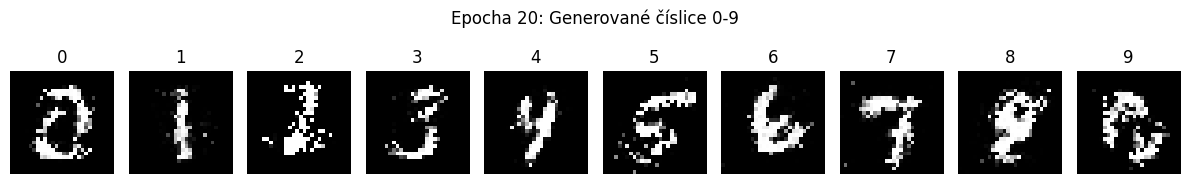

Epocha [21/50] | D Loss: 0.2969 | G Loss: 2.5149 | D Acc: 87.7%
Epocha [22/50] | D Loss: 0.2897 | G Loss: 2.6242 | D Acc: 88.1%
Epocha [23/50] | D Loss: 0.2901 | G Loss: 2.5825 | D Acc: 88.1%
Epocha [24/50] | D Loss: 0.2750 | G Loss: 2.7339 | D Acc: 88.8%
Epocha [25/50] | D Loss: 0.2907 | G Loss: 2.7037 | D Acc: 88.0%
Epocha [26/50] | D Loss: 0.2904 | G Loss: 2.6104 | D Acc: 87.9%
Epocha [27/50] | D Loss: 0.2780 | G Loss: 2.7204 | D Acc: 88.7%
Epocha [28/50] | D Loss: 0.2981 | G Loss: 2.6961 | D Acc: 87.5%
Epocha [29/50] | D Loss: 0.2845 | G Loss: 2.7282 | D Acc: 88.3%
Epocha [30/50] | D Loss: 0.2611 | G Loss: 2.8608 | D Acc: 89.5%


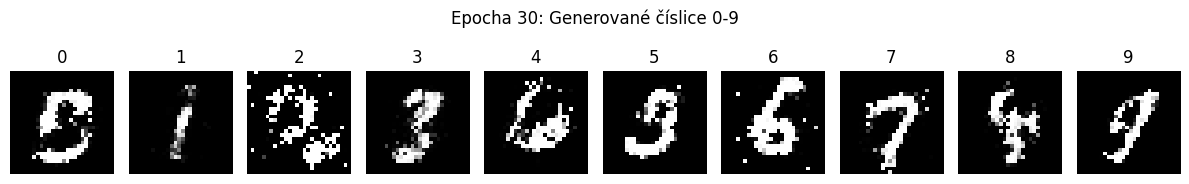

Epocha [31/50] | D Loss: 0.3147 | G Loss: 2.6973 | D Acc: 86.4%
Epocha [32/50] | D Loss: 0.3095 | G Loss: 2.6841 | D Acc: 86.7%
Epocha [33/50] | D Loss: 0.3053 | G Loss: 2.6032 | D Acc: 86.9%
Epocha [34/50] | D Loss: 0.3671 | G Loss: 2.2680 | D Acc: 83.5%
Epocha [35/50] | D Loss: 0.4186 | G Loss: 1.9502 | D Acc: 80.3%
Epocha [36/50] | D Loss: 0.4500 | G Loss: 1.8043 | D Acc: 78.5%
Epocha [37/50] | D Loss: 0.4667 | G Loss: 1.6799 | D Acc: 77.3%
Epocha [38/50] | D Loss: 0.4806 | G Loss: 1.5993 | D Acc: 76.4%
Epocha [39/50] | D Loss: 0.4694 | G Loss: 1.6300 | D Acc: 77.3%
Epocha [40/50] | D Loss: 0.4709 | G Loss: 1.5999 | D Acc: 77.3%


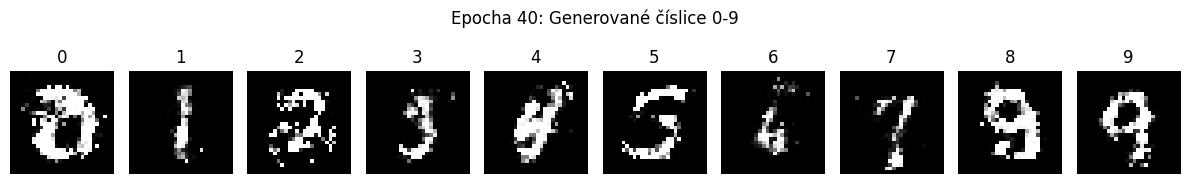

Epocha [41/50] | D Loss: 0.4756 | G Loss: 1.5749 | D Acc: 76.8%
Epocha [42/50] | D Loss: 0.4759 | G Loss: 1.6025 | D Acc: 77.0%
Epocha [43/50] | D Loss: 0.4791 | G Loss: 1.5462 | D Acc: 76.6%
Epocha [44/50] | D Loss: 0.4669 | G Loss: 1.5956 | D Acc: 77.5%
Epocha [45/50] | D Loss: 0.4833 | G Loss: 1.5501 | D Acc: 76.5%
Epocha [46/50] | D Loss: 0.4620 | G Loss: 1.6151 | D Acc: 77.9%
Epocha [47/50] | D Loss: 0.4612 | G Loss: 1.6108 | D Acc: 77.9%
Epocha [48/50] | D Loss: 0.4575 | G Loss: 1.6359 | D Acc: 78.2%
Epocha [49/50] | D Loss: 0.4649 | G Loss: 1.6016 | D Acc: 77.6%
Epocha [50/50] | D Loss: 0.4888 | G Loss: 1.5024 | D Acc: 76.1%


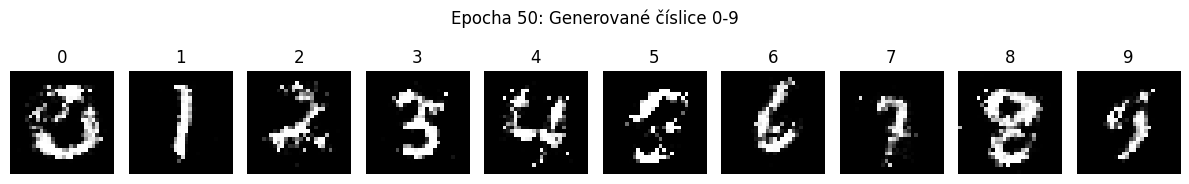


Trénovanie dokončené!


In [ ]:
print("="*60)
print("TRÉNOVANIE CONDITIONAL GAN")
print("="*60)

g_losses = []
d_losses = []
d_accuracies = []

for epoch in range(EPOCHS):
    epoch_g_loss = 0
    epoch_d_loss = 0
    epoch_d_acc = 0

    for i, (real_imgs, labels) in enumerate(train_loader):
        batch_size = real_imgs.size(0)
        real_imgs = real_imgs.to(device)
        labels = labels.to(device)

        # Labels
        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # Používame ROVNAKÉ labels pre real a fake!
        # Chceme generovať tú istú číslicu ako je na real obrázku

        # ============ Trénuj D ============
        optimizer_D.zero_grad()

        # Real
        real_validity = discriminator(real_imgs, labels)
        d_real_loss = adversarial_loss(real_validity, real_labels)

        # Fake (s rovnakými labels)
        z = torch.randn(batch_size, LATENT_DIM, device=device)
        fake_imgs = generator(z, labels)
        fake_validity = discriminator(fake_imgs.detach(), labels)
        d_fake_loss = adversarial_loss(fake_validity, fake_labels)

        d_loss = (d_real_loss + d_fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()

        # Presnosť diskriminátora
        real_acc = (real_validity > 0.5).float().mean()
        fake_acc = (fake_validity < 0.5).float().mean()
        d_acc = (real_acc + fake_acc) / 2

        # ============ Trénuj G ============
        optimizer_G.zero_grad()

        z = torch.randn(batch_size, LATENT_DIM, device=device)
        gen_imgs = generator(z, labels)
        validity = discriminator(gen_imgs, labels)

        g_loss = adversarial_loss(validity, real_labels)
        g_loss.backward()
        optimizer_G.step()

        epoch_g_loss += g_loss.item()
        epoch_d_loss += d_loss.item()
        epoch_d_acc += d_acc.item()

    avg_g = epoch_g_loss / len(train_loader)
    avg_d = epoch_d_loss / len(train_loader)
    avg_d_acc = epoch_d_acc / len(train_loader)
    g_losses.append(avg_g)
    d_losses.append(avg_d)
    d_accuracies.append(avg_d_acc)

    print(f"Epocha [{epoch+1}/{EPOCHS}] | "
              f"D Loss: {avg_d:.4f} | "
              f"G Loss: {avg_g:.4f} | "
              f"D Acc: {avg_d_acc*100:.1f}%")

    # Vizualizácia
    if (epoch + 1) % 10 == 0:
        generator.eval()
        with torch.no_grad():
            # Vygenerujeme všetky číslice (0-9)
            z = torch.randn(10, LATENT_DIM, device=device)
            labels_viz = torch.arange(10, device=device)
            samples = generator(z, labels_viz)
        generator.train()

        plt.figure(figsize=(12, 2))
        for i in range(10):
            plt.subplot(1, 10, i+1)
            plt.imshow(samples[i].cpu().squeeze(), cmap='gray')
            plt.title(f'{i}')
            plt.axis('off')
        plt.suptitle(f'Epocha {epoch+1}: Generované číslice 0-9')
        plt.tight_layout()
        plt.show()

print("\nTrénovanie dokončené!")

## 5. Generovanie špecifických číslic

GENEROVANIE ŠPECIFICKÝCH ČÍSLIC


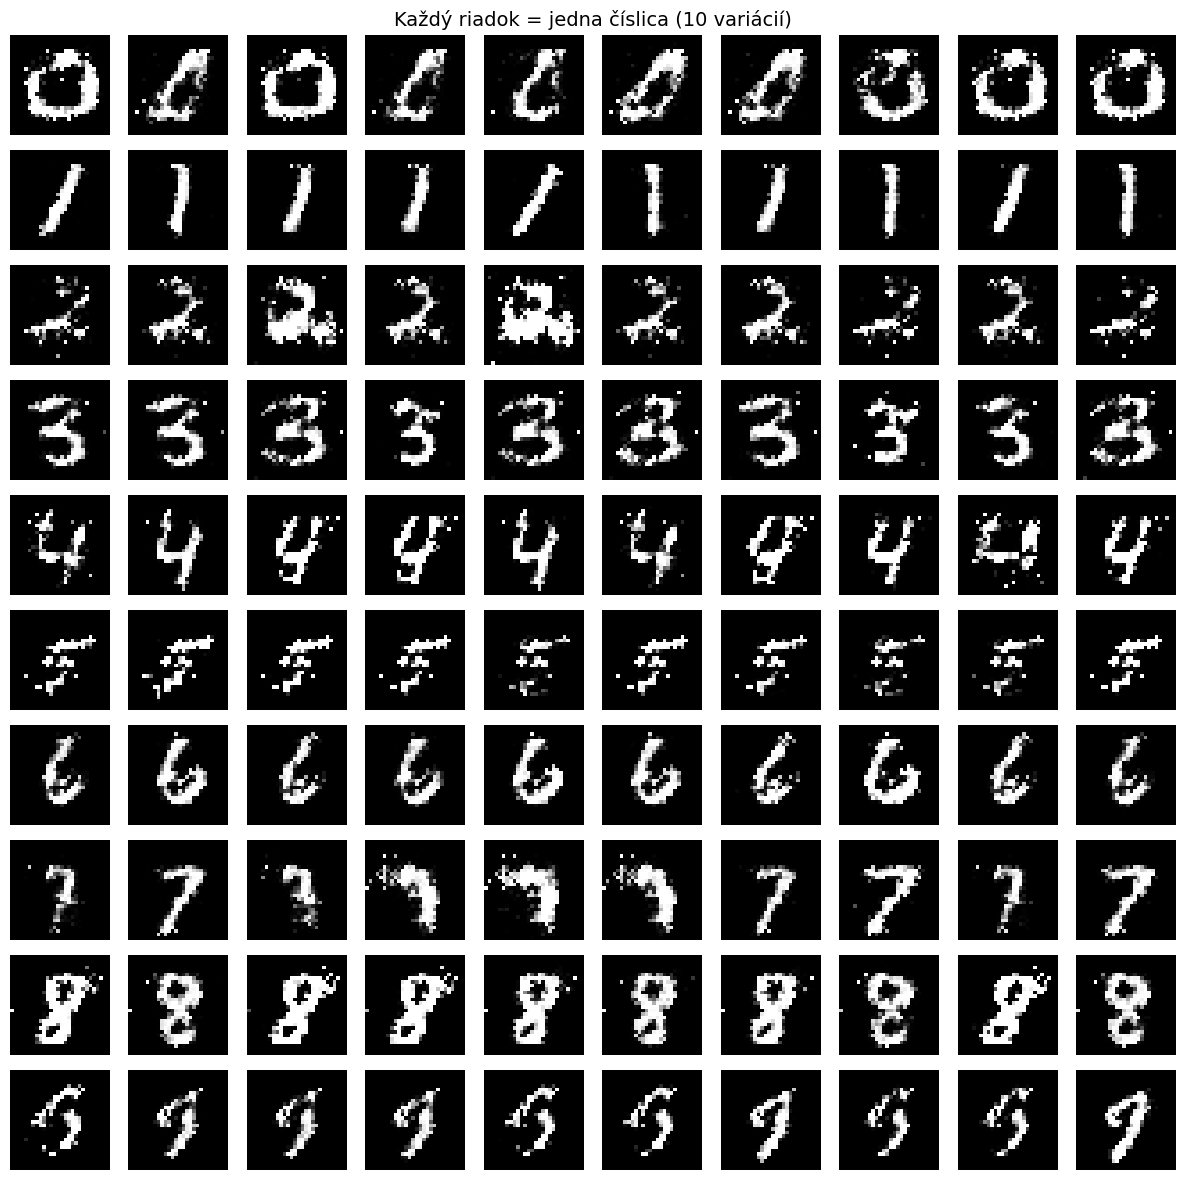

In [ ]:
print("="*60)
print("GENEROVANIE ŠPECIFICKÝCH ČÍSLIC")
print("="*60)

generator.eval()
with torch.no_grad():
    # Mriežka 10x10 (každý riadok = jedna číslica)
    z = torch.randn(100, LATENT_DIM, device=device)

    # Labels: 10× každá číslica
    labels = torch.tensor([i for i in range(10) for _ in range(10)], device=device)

    samples = generator(z, labels)

plt.figure(figsize=(12, 12))
for i in range(100):
    plt.subplot(10, 10, i+1)
    plt.imshow(samples[i].cpu().squeeze(), cmap='gray')
    plt.axis('off')
plt.suptitle('Každý riadok = jedna číslica (10 variácií)', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Experimenty

EXPERIMENT 1: Rovnaký šum, rôzne labels


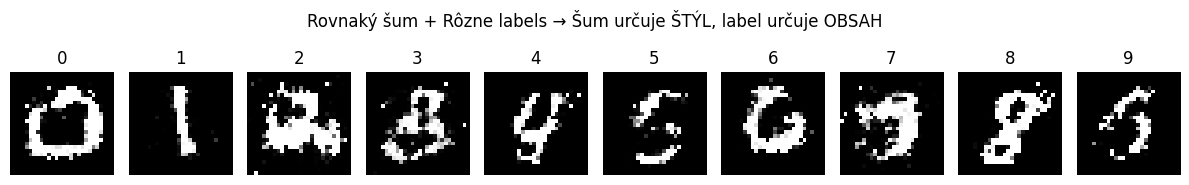

In [ ]:
print("="*60)
print("EXPERIMENT 1: Rovnaký šum, rôzne labels")
print("="*60)

generator.eval()
with torch.no_grad():
    # Jeden fixný šum
    z_fixed = torch.randn(1, LATENT_DIM, device=device).repeat(10, 1)

    # Rôzne labels 0-9
    labels = torch.arange(10, device=device)

    samples = generator(z_fixed, labels)

plt.figure(figsize=(12, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(samples[i].cpu().squeeze(), cmap='gray')
    plt.title(f'{i}')
    plt.axis('off')
plt.suptitle('Rovnaký šum + Rôzne labels → Šum určuje ŠTÝL, label určuje OBSAH', fontsize=12)
plt.tight_layout()
plt.show()

EXPERIMENT 2: Rovnaký label, rôzny šum


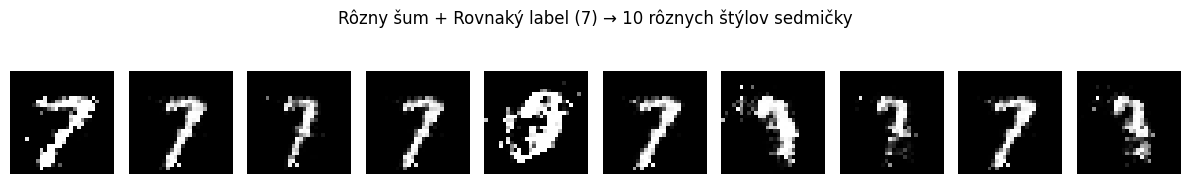

In [ ]:
print("="*60)
print("EXPERIMENT 2: Rovnaký label, rôzny šum")
print("="*60)

generator.eval()
with torch.no_grad():
    # Rôzny šum
    z = torch.randn(10, LATENT_DIM, device=device)

    # Fixný label (napríklad 7)
    labels = torch.tensor([7] * 10, device=device)

    samples = generator(z, labels)

plt.figure(figsize=(12, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(samples[i].cpu().squeeze(), cmap='gray')
    plt.axis('off')
plt.suptitle('Rôzny šum + Rovnaký label (7) → 10 rôznych štýlov sedmičky', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Interpolácia v label priestore

INTERPOLÁCIA: 0 → 7


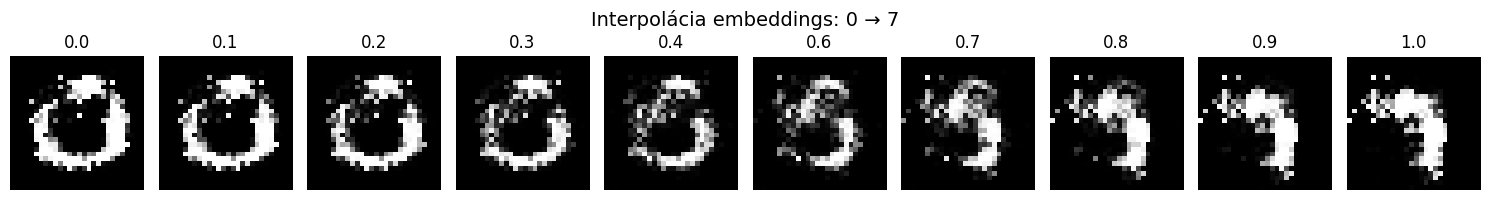

In [ ]:
print("="*60)
print("INTERPOLÁCIA: 0 → 7")
print("="*60)

generator.eval()
with torch.no_grad():
    # Fixný šum
    z = torch.randn(1, LATENT_DIM, device=device).repeat(10, 1)

    # Interpolácia embeddings
    label_0 = torch.tensor([0], device=device)
    label_7 = torch.tensor([7], device=device)

    emb_0 = generator.label_embedding(label_0)
    emb_7 = generator.label_embedding(label_7)

    steps = 10
    interpolated_imgs = []

    for alpha in np.linspace(0, 1, steps):
        emb_interp = (1 - alpha) * emb_0 + alpha * emb_7

        # Concatenate s šumom
        gen_input = torch.cat([z[0:1], emb_interp], dim=1)
        img = generator.model(gen_input)
        img = img.view(1, 1, 28, 28)
        interpolated_imgs.append(img.cpu().squeeze())

plt.figure(figsize=(15, 2))
for i, img in enumerate(interpolated_imgs):
    plt.subplot(1, steps, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f'{i/(steps-1):.1f}')
    plt.axis('off')
plt.suptitle('Interpolácia embeddings: 0 → 7', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Generovanie na požiadanie

Vygeneruj 5 variácií číslice 3:


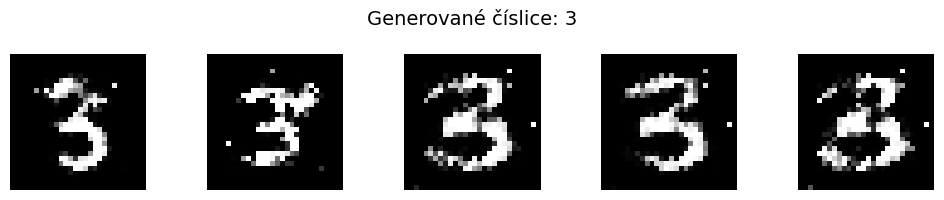


Vygeneruj 5 variácií číslice 8:


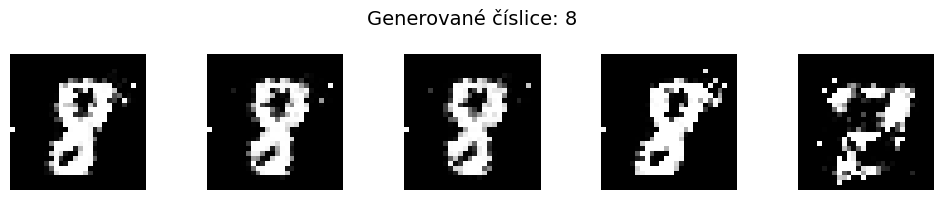

In [ ]:
def generate_digit(digit, num_samples=5):
    """Vygeneruje num_samples vzoriek danej číslice"""
    generator.eval()
    with torch.no_grad():
        z = torch.randn(num_samples, LATENT_DIM, device=device)
        labels = torch.tensor([digit] * num_samples, device=device)
        samples = generator(z, labels)

    plt.figure(figsize=(10, 2))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i+1)
        plt.imshow(samples[i].cpu().squeeze(), cmap='gray')
        plt.axis('off')
    plt.suptitle(f'Generované číslice: {digit}', fontsize=14)
    plt.tight_layout()
    plt.show()

# Demo
print("Vygeneruj 5 variácií číslice 3:")
generate_digit(3, 5)

print("\nVygeneruj 5 variácií číslice 8:")
generate_digit(8, 5)

## Záver

**Kľúčové poznatky:**

1. **Label embedding** umožňuje modelu "rozumieť" labels
2. **Šum určuje ŠTÝL**, **label určuje OBSAH**
3. Rovnaký šum + rôzne labels → rovnaký štýl písania, iný obsah
4. Rôzny šum + rovnaký label → rôzne štýly rovnakej číslice

Vytvorené s použitím Claude AI.